In [3]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader


In [4]:
'''
Fashion-MNIST
数据集第一列是标签，其后是784个像素点的灰度值，范围是0-255
'''
fashion_train = pd.read_csv('data/fashion-mnist_train.csv')
fashion_test = pd.read_csv('data/fashion-mnist_test.csv')

x_train = fashion_train.iloc[:, 1:].values
x_train = torch.tensor(x_train, dtype=torch.float32).reshape(-1, 1, 28, 28) #(N, C, H, W)

y_train = fashion_train.iloc[:, 0].values
y_train = torch.tensor(y_train, dtype=torch.int64)

x_test = fashion_test.iloc[:, 1:].values
x_test = torch.tensor(x_test, dtype=torch.float32).reshape(-1, 1, 28, 28)

y_test = fashion_test.iloc[:, 0].values
y_test = torch.tensor(y_test, dtype=torch.int64)

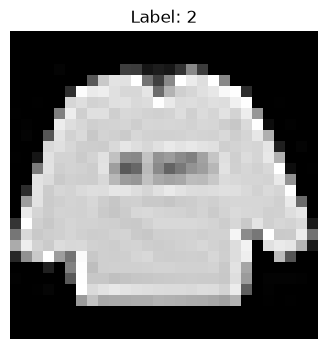

In [5]:
%matplotlib inline
# 画布大小
plt.figure(figsize=(4, 4))

plt.imshow(x_train[0, 0], cmap='gray')
plt.title(f"Label: {y_train[0].item()}")
plt.axis('off')

plt.show()

In [6]:
train_dataset = TensorDataset(x_train, y_train)
test_dataset = TensorDataset(x_test, y_test)

In [8]:
model = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2),  # (N, 6, 28, 28)
    nn.Sigmoid(),      
    nn.AvgPool2d(kernel_size=2, stride=2),  # (N, 6, 14, 14)

    nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0),  # (N, 16, 10, 10)
    nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),  # (N, 16, 5, 5)

    nn.Flatten(),  # (N, 16*5*5)

    nn.Linear(16*5*5, 120),
    nn.Sigmoid(),

    nn.Linear(120, 84),
    nn.Sigmoid(),
    
    nn.Linear(84, 10)
)

In [9]:
x = torch.randn(size=(1, 1, 28, 28), dtype=torch.float32)
for layer in model:
    x = layer(x)
    print(layer.__class__.__name__, 'output shape:\t', x.shape)

Conv2d output shape:	 torch.Size([1, 6, 28, 28])
Sigmoid output shape:	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape:	 torch.Size([1, 6, 14, 14])
Conv2d output shape:	 torch.Size([1, 16, 10, 10])
Sigmoid output shape:	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape:	 torch.Size([1, 16, 5, 5])
Flatten output shape:	 torch.Size([1, 400])
Linear output shape:	 torch.Size([1, 120])
Sigmoid output shape:	 torch.Size([1, 120])
Linear output shape:	 torch.Size([1, 84])
Sigmoid output shape:	 torch.Size([1, 84])
Linear output shape:	 torch.Size([1, 10])


In [12]:
def train_test(model, train_dataset, test_dataset, num_epochs, learning_rate, batch_size, device):
    # 初始化权重
    def init_weights(layer):
        if isinstance(layer, nn.Linear) or isinstance(layer, nn.Conv2d):
            # 配合Sigmoid激活函数使用Xavier初始化
            nn.init.xavier_uniform_(layer.weight)

    model.apply(init_weights)
    model.to(device)

    loss = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):
        model.train()
        train_loss, train_acc = 0.0, 0.0
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        for batch_idx, (X, y) in enumerate(train_loader):
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()

            output = model(X)
            l = loss(output, y)
            l.backward()
            optimizer.step()
    
            train_loss += l.item() * y.size(0)
            train_acc += (output.argmax(dim=1) == y).sum().item()
            
            # 进度条
            print(f"\rEpoch:{epoch + 1:0>2}[{'='* int((batch_idx + 1)/len(train_loader)*50)}]",end="") 
        
        n = len(train_dataset)
        this_loss = train_loss / n
        this_acc = train_acc / n

        model.eval()
        test_loader = DataLoader(test_dataset, batch_size=batch_size)

        test_acc = 0.0
        with torch.no_grad():
            for X_test, y_test in test_loader:
                X_test, y_test = X_test.to(device), y_test.to(device)
                output_test = model(X_test)
                
                pred = output_test.argmax(dim=1)
                test_acc += (pred == y_test).sum().item()

        this_test_acc = test_acc / len(test_dataset)

        print(f"Train Loss: {this_loss:.4f}, Train Acc: {this_acc :.4f}, "
              f"Test Acc: {this_test_acc:.4f}")

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

learning_rate = 0.1
num_epochs = 20
batch_size = 256

train_test(model, train_dataset, test_dataset, num_epochs, learning_rate, batch_size, device)



Epoch:01[==================================================]Train Loss: 2.2965, Train Acc: 0.1276, Test Acc: 0.1565
Epoch:02[==================================================]Train Loss: 2.0567, Train Acc: 0.3234, Test Acc: 0.4239
Epoch:03[==================================================]Train Loss: 1.3090, Train Acc: 0.5506, Test Acc: 0.5739
Epoch:04[==================================================]Train Loss: 1.0692, Train Acc: 0.6052, Test Acc: 0.5877
Epoch:05[==================================================]Train Loss: 0.9577, Train Acc: 0.6410, Test Acc: 0.6424
Epoch:06[==================================================]Train Loss: 0.8752, Train Acc: 0.6730, Test Acc: 0.6379
Epoch:07[==================================================]Train Loss: 0.8113, Train Acc: 0.7011, Test Acc: 0.7106
Epoch:08[==================================================]Train Loss: 0.7633, Train Acc: 0.7225, Test Acc: 0.7092
Epoch:09[==================================================]Train Loss: 

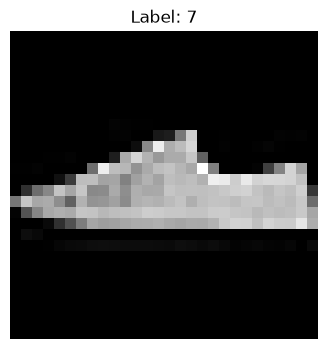

Predicted Label: 7, True Label: 7


In [18]:
import random
%matplotlib inline

plt.figure(figsize=(4, 4))
x = random.randint(0, len(x_test) - 1)
plt.imshow(x_test[ x, 0], cmap='gray')
plt.title(f"Label: {y_test[x].item()}")
plt.axis('off')

plt.show()

output = model(x_test[x].unsqueeze(0).to(device))
predicted_label = output.argmax(dim=1).item()
print(f"Predicted Label: {predicted_label}, True Label: {y_test[x].item()}")

In [ ]:

torch.save(model.state_dict(), 'model/fashion_mnist_cnn.pth')
print("模型已保存: model/fashion_mnist_cnn.pth")

模型已保存:fashion_mnist_cnn.pth


In [ ]:
# 实例化相同的模型结构
model_loaded = model 

# 加载参数
model_loaded.load_state_dict(torch.load('model/fashion_mnist_cnn.pth'))

# 切换到评估模式，并移到设备上
model_loaded.to(device)
model_loaded.eval()

Sequential(
  (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (1): Sigmoid()
  (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (4): Sigmoid()
  (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=400, out_features=120, bias=True)
  (8): Sigmoid()
  (9): Linear(in_features=120, out_features=84, bias=True)
  (10): Sigmoid()
  (11): Linear(in_features=84, out_features=10, bias=True)
)